# LightGBM for Sales Drop Detection — Full Product Catalogue

## Overview

This notebook applies the winning model architecture — LightGBM — to the full retail 
product catalogue of approximately 10,000 SKUs, extending the top-500 baseline study 
to production scale. The core task is identifying hours when a product is physically 
available in stock but its sales have unexpectedly collapsed — a pattern indicative of 
shelf availability failures.

The dataset covers hourly sales records for January–July 2025 (training) and August 
2025 (test). Ground-truth anomaly labels are unavailable; evaluation relies on 65 
manually injected zero-sales events as a controlled recall benchmark, supplemented by 
statistical quality diagnostics on the full set of detected anomalies.

## Position in the Research Pipeline

Three earlier notebooks established the comparative baseline on the top-500 products 
by August sales volume:

*   **LightGBM_for_Sales_Drop_Detection** — trained LightGBM and tested four 
    thresholding strategies (z > 2.0, z > 3.0, z > 4.0, z > 5.0).
*   **TCN_for_Sales_Drop_Detection** — trained a global Temporal Convolutional Network 
    with identical loss function and anomaly scoring, enabling a fair head-to-head comparison.
*   **Anomaly_Detection_Model_Selection_via_Statistical_Diagnostics** — applied a 
    structured evaluation framework across LightGBM, TCN, and Isolation Forest. LightGBM 
    emerged as the clear winner on signal strength, product coverage, operational alert 
    volume, and interpretability.

## Why LightGBM and What This Notebook Adds

LightGBM was selected for three structural reasons: scalability to 10,000 SKUs in a 
single training pass, direct feature importance for operational interpretability, and 
stronger anomaly signal quality in the head-to-head evaluation (mean |z_hist| 0.667 
vs 0.471 for TCN, with 3× broader product coverage).

This notebook extends LightGBM to the full catalogue with two improvements:

**Extended product profile features.** Thirteen historical statistics are pre-computed 
per product using only pre-August data: mean, standard deviation, coefficient of 
variation, zero-sale rate, ADI, maximum, 99th percentile, peak-to-mean ratio, outlier 
rate, positive-sale rate, acceleration, recent-vs-average ratio, and 3-day volatility. 
These encode demand heterogeneity across a diverse mix of fast-movers and slow-movers.

**Four-configuration benchmark.** Two loss functions (RMSE and Huber) × two 
regularisation regimes (conservative and strong) are evaluated at four z-score 
thresholds (z > 2.0, z > 3.0, z > 4.0, z > 5.0). Final configuration selection 
balances recall against operational alert volume — a primary constraint in a 
discount-format retail environment with limited staff.

The mandatory domain filter — positive stock in the current and preceding hour, 
detection restricted to business hours 07:00–22:00 — is applied identically to all 
configurations.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import gc
from sklearn.metrics import mean_squared_error

DATA_PATH       = r'C:\Users\User\Desktop\диплом\data_v1.csv'
AUG_FULL_PATH   = r'C:\Users\User\Desktop\диплом\df_aug_final.csv'
AUG_ZERO_PATH   = r'C:\Users\User\Desktop\диплом\df_aug_final_check_rows.csv'

print("LightGBM version:", lgb.__version__)

LightGBM version: 4.6.0


### Data Loading and Cold-Start Filtering

Loads the main sales dataset and two augmentation files. Converts date columns to datetime format, removes products that had their first sale after 1 August 2025 (cold-start products), and filters the main dataframe to data up to 31 August 2025.

In [2]:
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

first_pos = df[df['sales'] > 0].groupby('product')['date'].min()
aug_start = pd.Timestamp('2025-08-01')
cold = first_pos[first_pos >= aug_start].index.tolist()
df = df[~df['product'].isin(cold)].copy()
print(f"After removing cold-start: {df.shape[0]:,} rows | {df['product'].nunique():,} products")

df_aug = pd.read_csv(AUG_FULL_PATH)
df_aug_zero = pd.read_csv(AUG_ZERO_PATH)
df_aug['date'] = pd.to_datetime(df_aug['date'])
df_aug_zero['date'] = pd.to_datetime(df_aug_zero['date'])
df = df[df['date'] <= '2025-08-31'].copy()

After removing cold-start: 59,441,640 rows | 7,775 products


### Product Profile Feature Engineering

Creates a rich product-level profile using only data before September 2025. Calculates 13 historical statistical features for each product (mean, standard deviation, coefficient of variation, zero rate, ADI, maximum, 99th percentile, peak ratio, outlier rate, positive sales rate, acceleration, recent vs average ratio, and 3-day volatility). Merges the features back to the products table and imputes missing values using category medians.

In [3]:
df_til_sep = df[df['date'].dt.month < 8].copy()

products = df_til_sep[['product', 'category']].drop_duplicates()
first_sales = (df_til_sep[df_til_sep['sales'] > 0].groupby('product')['date'].min().reset_index())
first_sales.columns = ['product', 'first_sale_date']
products = products.merge(first_sales, on='product', how='left')

df_active = df_til_sep.merge(first_sales[['product', 'first_sale_date']], on='product', how='left')
df_active = df_active[df_active['date'] >= df_active['first_sale_date']]

all_features = df_active.groupby('product').agg(
    hist_mean=('sales','mean'), hist_std=('sales','std'),
    hist_cv=('sales', lambda x: x.std()/(x.mean()+1e-6)),
    hist_zero=('sales', lambda x: (x==0).mean()),
    hist_adi=('sales', lambda x: (x==0).sum() / max((x>0).sum(),1)),
    hist_max=('sales','max'), hist_p99=('sales', lambda x: np.percentile(x,99)),
    hist_peak=('sales', lambda x: x.max()/(x.mean()+1e-6)),
    hist_outlier=('sales', lambda x: (x > np.percentile(x,99)).mean()),
    hist_pos_rate=('sales', lambda x: (x>0).mean()),
    accel=('sales', lambda x: x.iloc[-72:].mean() / (x.iloc[:72].mean()+1e-6) if len(x)>=144 else 1.0),
    recent_vs_avg=('sales', lambda x: x.iloc[-72:].mean() / (x.mean()+1e-6)),
    vol_3d=('sales', lambda x: x.iloc[-72:].std() / (x.iloc[-72:].mean()+1e-6) if len(x)>=72 else 0.0)
).reset_index()

products = products.merge(all_features, on='product', how='left')
del df_active, all_features, first_sales
gc.collect()

profile_cols = ['hist_mean','hist_std','hist_cv','hist_zero','hist_adi','hist_max','hist_p99',
                'hist_peak','hist_outlier','hist_pos_rate','accel','recent_vs_avg','vol_3d']
for col in profile_cols:
    med = products.groupby('category')[col].median()
    products.loc[products[col].isna(), col] = products.loc[products[col].isna(), 'category'].map(med)
products[profile_cols] = products[profile_cols].replace([np.inf,-np.inf],np.nan).fillna(0).astype('float32')

### Full Feature Engineering

Merges the product profile features into the main time-series dataframe. Creates calendar features (hour, day of week, weekend flag, week number), lag features (1h, 24h, 168h), and advanced rolling statistics (mean and std for 6h, 24h, 168h windows). Adds derived features: 24h z-score, 1h and 24h percentage changes, and sales-to-rolling-mean ratio. Replaces infinities and missing values with zero.

In [4]:
df_til_sep = df[df['date'] <= '2025-07-31'].copy()
df_til_sep = df_til_sep.merge(products, on=['product','category'], how='left').sort_values(['product','date']).reset_index(drop=True)

df_til_sep['hour'] = df_til_sep['date'].dt.hour
df_til_sep['dayofweek'] = df_til_sep['date'].dt.dayofweek
df_til_sep['is_weekend'] = (df_til_sep['dayofweek'] >= 5).astype(int)
df_til_sep['week'] = df_til_sep['date'].dt.isocalendar().week

for lag in [1, 24, 168]:
    df_til_sep[f'sales_lag_{lag}h'] = df_til_sep.groupby('product')['sales'].shift(lag)

df_til_sep['stocks_lag_1h'] = df_til_sep.groupby('product')['stocks'].shift(1).fillna(0)

for w in [6, 24, 168]:
    min_periods = max(1, w // 2)
    df_til_sep[f'rolling_mean_{w}h'] = df_til_sep.groupby('product')['sales'].transform(
        lambda x: x.rolling(w, min_periods=min_periods).mean()
    )
    df_til_sep[f'rolling_std_{w}h'] = df_til_sep.groupby('product')['sales'].transform(
        lambda x: x.rolling(w, min_periods=min_periods).std()
    )

df_til_sep['z_score_24h'] = (df_til_sep['sales'] - df_til_sep['rolling_mean_24h']) / (df_til_sep['rolling_std_24h'] + 1e-6)
df_til_sep['pct_change_1h'] = df_til_sep.groupby('product')['sales'].pct_change(1)
df_til_sep['pct_change_24h'] = df_til_sep.groupby('product')['sales'].pct_change(24)
df_til_sep['sales_vs_mean_24h'] = df_til_sep['sales'] / (df_til_sep['rolling_mean_24h'] + 1e-6)

num_cols = df_til_sep.select_dtypes(include=['float32','float64','int32','int64']).columns
df_til_sep[num_cols] = df_til_sep[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

### Train / Test Split and Feature Preparation

Splits the data into training set (months before August 2025) and test set (August data). Adds all engineered features from the training dataframe to the test set, creates missing calendar features for the test set, defines the final list of model features, prepares X_train/y_train and X_test/y_test, prints dataset sizes, and frees memory.

In [5]:
df_train = df_til_sep[df_til_sep['date'].dt.month < 8].copy()

df_aug_orig = df[df['date'] >= '2025-08-01'].copy()
df_aug_orig = df_aug_orig.merge(
    df_til_sep[['product'] + profile_cols].drop_duplicates('product'),
    on='product', how='left'
)

df_aug_orig = df_aug_orig.sort_values(['product', 'date'])
df_aug_orig['stocks_lag_1h'] = df_aug_orig.groupby('product')['stocks'].shift(1).fillna(0)
df_aug_orig['hour']       = df_aug_orig['date'].dt.hour
df_aug_orig['dayofweek']  = df_aug_orig['date'].dt.dayofweek
df_aug_orig['is_weekend'] = (df_aug_orig['dayofweek'] >= 5).astype(int)
df_aug_orig['week']       = df_aug_orig['date'].dt.isocalendar().week

for lag in [1, 24, 168]:
    df_aug_orig[f'sales_lag_{lag}h'] = df_aug_orig.groupby('product')['sales'].shift(lag)

for w in [6, 24, 168]:
    min_periods = max(1, w // 2)
    df_aug_orig[f'rolling_mean_{w}h'] = df_aug_orig.groupby('product')['sales'].transform(
        lambda x: x.rolling(w, min_periods=min_periods).mean()
    )
    df_aug_orig[f'rolling_std_{w}h'] = df_aug_orig.groupby('product')['sales'].transform(
        lambda x: x.rolling(w, min_periods=min_periods).std()
    )

df_aug_orig['z_score_24h']       = (df_aug_orig['sales'] - df_aug_orig['rolling_mean_24h']) / (df_aug_orig['rolling_std_24h'] + 1e-6)
df_aug_orig['pct_change_1h']     = df_aug_orig.groupby('product')['sales'].pct_change(1)
df_aug_orig['pct_change_24h']    = df_aug_orig.groupby('product')['sales'].pct_change(24)
df_aug_orig['sales_vs_mean_24h'] = df_aug_orig['sales'] / (df_aug_orig['rolling_mean_24h'] + 1e-6)

num_cols = df_aug_orig.select_dtypes(include=['float32','float64','int32','int64']).columns
df_aug_orig[num_cols] = df_aug_orig[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

df_aug_orig = df_aug_orig.merge(
    df_aug_zero[['product','date']].assign(is_injected=1),
    on=['product','date'], how='left'
)
df_aug_orig.loc[df_aug_orig['is_injected'] == 1, 'sales'] = 0
df_aug_orig = df_aug_orig.drop(columns='is_injected')

df_test = df_aug_orig.copy()

exclude = ['product','date','category','first_sale_date','sales','price']
features = [c for c in df_til_sep.columns if c not in exclude]

X_train, y_train = df_train[features], df_train['sales']
X_test, y_test   = df_test[features], df_test['sales']
print(f"Train: {len(X_train):,} | Test: {len(X_test):,} | Features: {len(features)}")

del df_til_sep, products
gc.collect()

Train: 36,388,440 | Test: 5,081,486 | Features: 32


0

### Core Training and Anomaly Detection Function

Defines the main function `train_and_detect` that trains a LightGBM model with early stopping on a July validation split, predicts on the test set, calculates residuals and z-scores, applies a mandatory filter (stock available + business hours 7–22), detects anomalies at multiple z-score thresholds, computes recall against the 65 labelled zero-sales cases, and stores the detected anomalies for later analysis.

In [6]:
saved_anomalies = {}

def train_and_detect(model_name, objective, z_thresholds, strong_params=False):
    results = []
    
    val_mask = (df_train['date'] >= '2025-07-25') & (df_train['date'] < '2025-08-01')
    X_val = df_train.loc[val_mask, features]
    y_val = df_train.loc[val_mask, 'sales']
    sample_weight_val = np.where(y_val > 0, 3, 1)
    
    if strong_params:
        params = {
            'objective': objective,
            'metric': 'mae',
            'learning_rate': 0.05,
            'n_estimators': 1200,
            'num_leaves': 48,
            'max_depth': 7,
            'min_child_samples': 150,
            'reg_alpha': 0.3,
            'reg_lambda': 0.8,
            'min_split_gain': 0.05,
            'subsample': 0.75,
            'colsample_bytree': 0.65,
            'path_smooth': 8,
            'max_bin': 255,
            'verbose': -1,
            'random_state': 42,
            'n_jobs': -1
        }
        if objective == 'huber':
            params['alpha'] = 0.9
    else:
        params = {
            'objective': objective,
            'metric': 'mae' if objective == 'huber' else 'rmse',
            'learning_rate': 0.03,
            'n_estimators': 1200,
            'num_leaves': 31,
            'max_depth': 7,
            'min_child_samples': 200,
            'reg_alpha': 0.5,
            'reg_lambda': 1.0,
            'subsample': 0.7,
            'colsample_bytree': 0.6,
            'max_bin': 255,
            'verbose': -1,
            'random_state': 42,
            'n_jobs': -1
        }
        if objective == 'huber':
            params['alpha'] = 0.9

    model = lgb.LGBMRegressor(**params)
    sample_weight = np.where(y_train > 0, 3, 1)
    
    model.fit(
        X_train, y_train,
        sample_weight=sample_weight,
        eval_set=[(X_val, y_val)],
        eval_sample_weight=[sample_weight_val],
        callbacks=[
            lgb.early_stopping(stopping_rounds=10, verbose=True),
            lgb.log_evaluation(period=100)
        ]
    )
    
    print(f"Best iteration: {model.best_iteration_}")

    df_test_local = df_test.copy()
    df_test_local['predicted_sales'] = model.predict(X_test)
    df_test_local['residual'] = df_test_local['predicted_sales'] - df_test_local['sales']
    df_test_local['residual_zscore'] = (df_test_local['residual'] - df_test_local['residual'].mean()) / df_test_local['residual'].std()

    df_test_local['mandatory_filter'] = (
        (df_test_local['stocks_lag_1h'] > 0) &
        (df_test_local['stocks'] > 0) &
        (df_test_local['hour'] >= 7) &
        (df_test_local['hour'] <= 22)
    )

    for z in z_thresholds:
        df_test_local['is_anomaly'] = df_test_local['mandatory_filter'] & (df_test_local['residual_zscore'] > z)
        anomalies = df_test_local[df_test_local['is_anomaly']]
        
        matches = len(anomalies.merge(df_aug_zero[['product', 'date']], on=['product', 'date'], how='inner'))
        total = len(anomalies)
        unique_products = anomalies['product'].nunique() if total > 0 else 0

        saved_anomalies[(model_name, z)] = anomalies[['date', 'product', 'category', 'sales', 'stocks', 'price']].copy()
        
        results.append({
            'model': model_name,
            'z_threshold': z,
            'total_anomalies': total,
            'unique_products': unique_products,
            'matches_labelled': matches,
            'recall_on_65': round(matches / 65 * 100, 1)
        })
        print(f"{model_name} | z > {z}: {total:,} anomalies | {unique_products} products | {matches} matches ({round(matches/65*100,1)}%)")
    
    return results, df_test_local

z_thresholds = [2.0, 3.0, 4.0, 5.0]

Four z-score thresholds are evaluated: z > 2.0, z > 3.0, z > 4.0, z > 5.0. 
The lower thresholds (2.0, 3.0) serve as diagnostic baselines to understand 
alert volume at relaxed sensitivity; the operationally viable range identified 
in the top-500 experiment was z > 4.0 and above.

### Final Model Comparison and Results

Runs all four model configurations (RMSE conservative, Huber conservative, RMSE strong, Huber strong), collects performance metrics, prints a final comparative table, and identifies the best model by recall and operational alert volume as well as the overall best model based on recall against the 65 labelled zero-sales anomalies.

In [7]:
all_results = []

print("1/4 RMSE conservative")
res1, df_rmse_cons = train_and_detect("1. RMSE conservative", "regression", z_thresholds, strong_params=False)
all_results.extend(res1)

print("\n2/4 Huber conservative")
res2, df_huber_cons = train_and_detect("2. Huber conservative", "huber", z_thresholds, strong_params=False)
all_results.extend(res2)

print("\n3/4 RMSE strong")
res3, df_rmse_strong = train_and_detect("3. RMSE strong", "regression", z_thresholds, strong_params=True)
all_results.extend(res3)

print("\n4/4 Huber strong")
res4, df_huber_strong = train_and_detect("4. Huber strong", "huber", z_thresholds, strong_params=True)
all_results.extend(res4)

results_df = pd.DataFrame(all_results)
print("\nRecall")
print(results_df.to_string(index=False))

1/4 RMSE conservative
Training until validation scores don't improve for 10 rounds
[100]	valid_0's rmse: 0.167799
[200]	valid_0's rmse: 0.113457
[300]	valid_0's rmse: 0.0960151
[400]	valid_0's rmse: 0.0890847
[500]	valid_0's rmse: 0.084395
[600]	valid_0's rmse: 0.0815585
Early stopping, best iteration is:
[652]	valid_0's rmse: 0.0800383
Best iteration: 652
1. RMSE conservative | z > 2.0: 2,934 anomalies | 745 products | 63 matches (96.9%)
1. RMSE conservative | z > 3.0: 1,212 anomalies | 281 products | 63 matches (96.9%)
1. RMSE conservative | z > 4.0: 869 anomalies | 203 products | 62 matches (95.4%)
1. RMSE conservative | z > 5.0: 677 anomalies | 162 products | 61 matches (93.8%)

2/4 Huber conservative
Training until validation scores don't improve for 10 rounds
[100]	valid_0's l1: 0.0666096
[200]	valid_0's l1: 0.0332964
[300]	valid_0's l1: 0.0240903
[400]	valid_0's l1: 0.019159
[500]	valid_0's l1: 0.0161426
[600]	valid_0's l1: 0.0139523
[700]	valid_0's l1: 0.0123964
[800]	valid_0's

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

model_preds = {
    '1. RMSE conservative':  df_rmse_cons,
    '2. Huber conservative': df_huber_cons,
    '3. RMSE strong':        df_rmse_strong,
    '4. Huber strong':       df_huber_strong,
}

print(f"{'model':<25} {'MAE':>8} {'RMSE':>8} {'% hours with sales':>20}")

for name, df_p in model_preds.items():
    mae  = mean_absolute_error(df_p['sales'], df_p['predicted_sales'])
    rmse = mean_squared_error(df_p['sales'], df_p['predicted_sales']) ** 0.5
    pos  = (df_p['sales'] > 0).mean() * 100
    print(f"{name:<25} {mae:>8.4f} {rmse:>8.4f} {pos:>20.1f}%")

model                          MAE     RMSE   % hours with sales
1. RMSE conservative        0.0068   0.1880                  4.5%
2. Huber conservative       0.0066   0.2986                  4.5%
3. RMSE strong              0.0061   0.1730                  4.5%
4. Huber strong             0.0049   0.2519                  4.5%


### Anomaly Quality Evaluation

Defines a detailed evaluation function `evaluate_anomalies` that computes 20+ quality metrics for any set of detected anomalies (historical and July deviation, z-scores, zero-sales rate, stock availability at anomaly time, temporal patterns, etc.). Reloads the full original dataset, evaluates all saved anomaly sets from the four models, and prints a transposed comparative table.

In [11]:
def evaluate_anomalies(anomaly_df, full_df, test_start="2025-08-01"):
    pre_test = full_df[full_df['date'] < test_start].copy()
    first_pos = (pre_test[pre_test['sales'] > 0]
                 .groupby('product')['date'].min()
                 .reset_index(name='first_positive_date'))
    pre_test = pre_test.merge(first_pos, on='product', how='left')
    pre_test = pre_test[pre_test['date'] >= pre_test['first_positive_date']].copy()
    
    stats_full = pre_test.groupby('product').agg(
        mean_sales_hist = ('sales', 'mean'),
        std_sales_hist = ('sales', 'std'),
        median_sales_hist = ('sales', 'median'),
    ).reset_index()
    
    stats_july = (pre_test[pre_test['date'].dt.month == 7]
                  .groupby('product').agg(
                      mean_sales_july = ('sales', 'mean'),
                      std_sales_july = ('sales', 'std'),
                  ).reset_index())
    
    anom = anomaly_df.copy()
    anom['date'] = pd.to_datetime(anom['date'])
    anom['product'] = anom['product'].astype(str)
    anom['hour'] = anom['date'].dt.hour
    anom['weekday'] = anom['date'].dt.dayofweek
    
    anom = anom.merge(stats_full, on='product', how='left')
    anom = anom.merge(stats_july, on='product', how='left')
    
    for col in ['std_sales_hist', 'std_sales_july', 'mean_sales_hist', 'mean_sales_july']:
        anom[col] = anom[col].replace(0, np.nan).fillna(1)
    
    anom['z_hist'] = (anom['sales'] - anom['mean_sales_hist']) / anom['std_sales_hist']
    anom['z_july'] = (anom['sales'] - anom['mean_sales_july']) / anom['std_sales_july']
    anom['dev_pct_hist'] = (anom['sales'] - anom['mean_sales_hist']) / anom['mean_sales_hist'] * 100
    anom['dev_pct_july'] = (anom['sales'] - anom['mean_sales_july']) / anom['mean_sales_july'] * 100
    
    stock_prev = full_df[['date', 'product', 'stocks']].rename(columns={'stocks': 'stocks_prev', 'date': 'prev_date'})
    anom['prev_date'] = anom['date'] - pd.Timedelta(hours=1)
    anom = anom.merge(stock_prev, on=['prev_date', 'product'], how='left')
    
    drop_mask = anom['sales'] < anom['mean_sales_hist']
    zero_mask = anom['sales'] == 0
    deep_drop_mask = anom['dev_pct_hist'] < -50
    stock_ok_mask = (anom['stocks_prev'] > 0) & (anom['stocks'] > 0)
    n = len(anom)
    
    return {
        'Anomalies found': n,
        'Unique products': anom['product'].nunique(),
        'Unique days': anom['date'].dt.date.nunique(),
        'Anomalies/day (avg)': round(n / max(anom['date'].dt.date.nunique(), 1), 1),
        'Mean deviation from norm (%)': round(anom.loc[drop_mask, 'dev_pct_hist'].mean(), 1),
        'Median deviation from norm (%)': round(anom.loc[drop_mask, 'dev_pct_hist'].median(), 1),
        'Mean deviation from July (%)': round(anom.loc[drop_mask, 'dev_pct_july'].mean(), 1),
        'Mean |z_hist|': round(anom['z_hist'].abs().mean(), 3),
        'Mean |z_july|': round(anom['z_july'].abs().mean(), 3),
        '% |z_hist| > 2': round((anom['z_hist'].abs() > 2).mean() * 100, 1),
        '% |z_hist| > 3': round((anom['z_hist'].abs() > 3).mean() * 100, 1),
        '% |z_july| > 2': round((anom['z_july'].abs() > 2).mean() * 100, 1),
        '% |z_july| > 3': round((anom['z_july'].abs() > 3).mean() * 100, 1),
        '% zero sales': round(zero_mask.mean() * 100, 1),
        '% drops > 50% below norm': round(deep_drop_mask.mean() * 100, 1),
        '% anomalies with stock': round(stock_ok_mask.mean() * 100, 1),
        'Zero stock at anomaly time (count)': int((anom['stocks'] == 0).sum()),
        'Zero stock previous hour (count)': int((anom['stocks_prev'] == 0).sum()),
        'Peak hour (mode)': int(anom['hour'].mode().iloc[0]) if n > 0 else None,
        '% working hours (7–22)': round(((anom['hour'] >= 7) & (anom['hour'] <= 22)).mean() * 100, 1),
        '% weekdays': round((anom['weekday'] < 5).mean() * 100, 1),
    }

full_df = df.copy()
full_df['date'] = pd.to_datetime(full_df['date'])

eval_rows = []
for (model_name, z), anom_df in saved_anomalies.items():
    metrics = evaluate_anomalies(anom_df, full_df)
    metrics['LightGBM configuration'] = model_name
    metrics['z_threshold'] = z
    eval_rows.append(metrics)

eval_df = pd.DataFrame(eval_rows).set_index(['LightGBM configuration', 'z_threshold'])
print(eval_df.T.to_string())

LightGBM configuration             1. RMSE conservative                             2. Huber conservative                            3. RMSE strong                             4. Huber strong                           
z_threshold                                         2.0       3.0      4.0      5.0                   2.0      3.0      4.0      5.0            2.0       3.0      4.0      5.0             2.0      3.0      4.0      5.0
Anomalies found                                2934.000  1212.000  869.000  677.000              1068.000  410.000  214.000  139.000       3026.000  1809.000  945.000  716.000        1256.000  525.000  392.000  312.000
Unique products                                 745.000   281.000  203.000  162.000               406.000  136.000   58.000   34.000        760.000   528.000  222.000  159.000         446.000  153.000  127.000  108.000
Unique days                                      30.000    30.000   30.000   30.000                30.000   30.000   30.000 

### Predicted vs Actual Sales Visualization

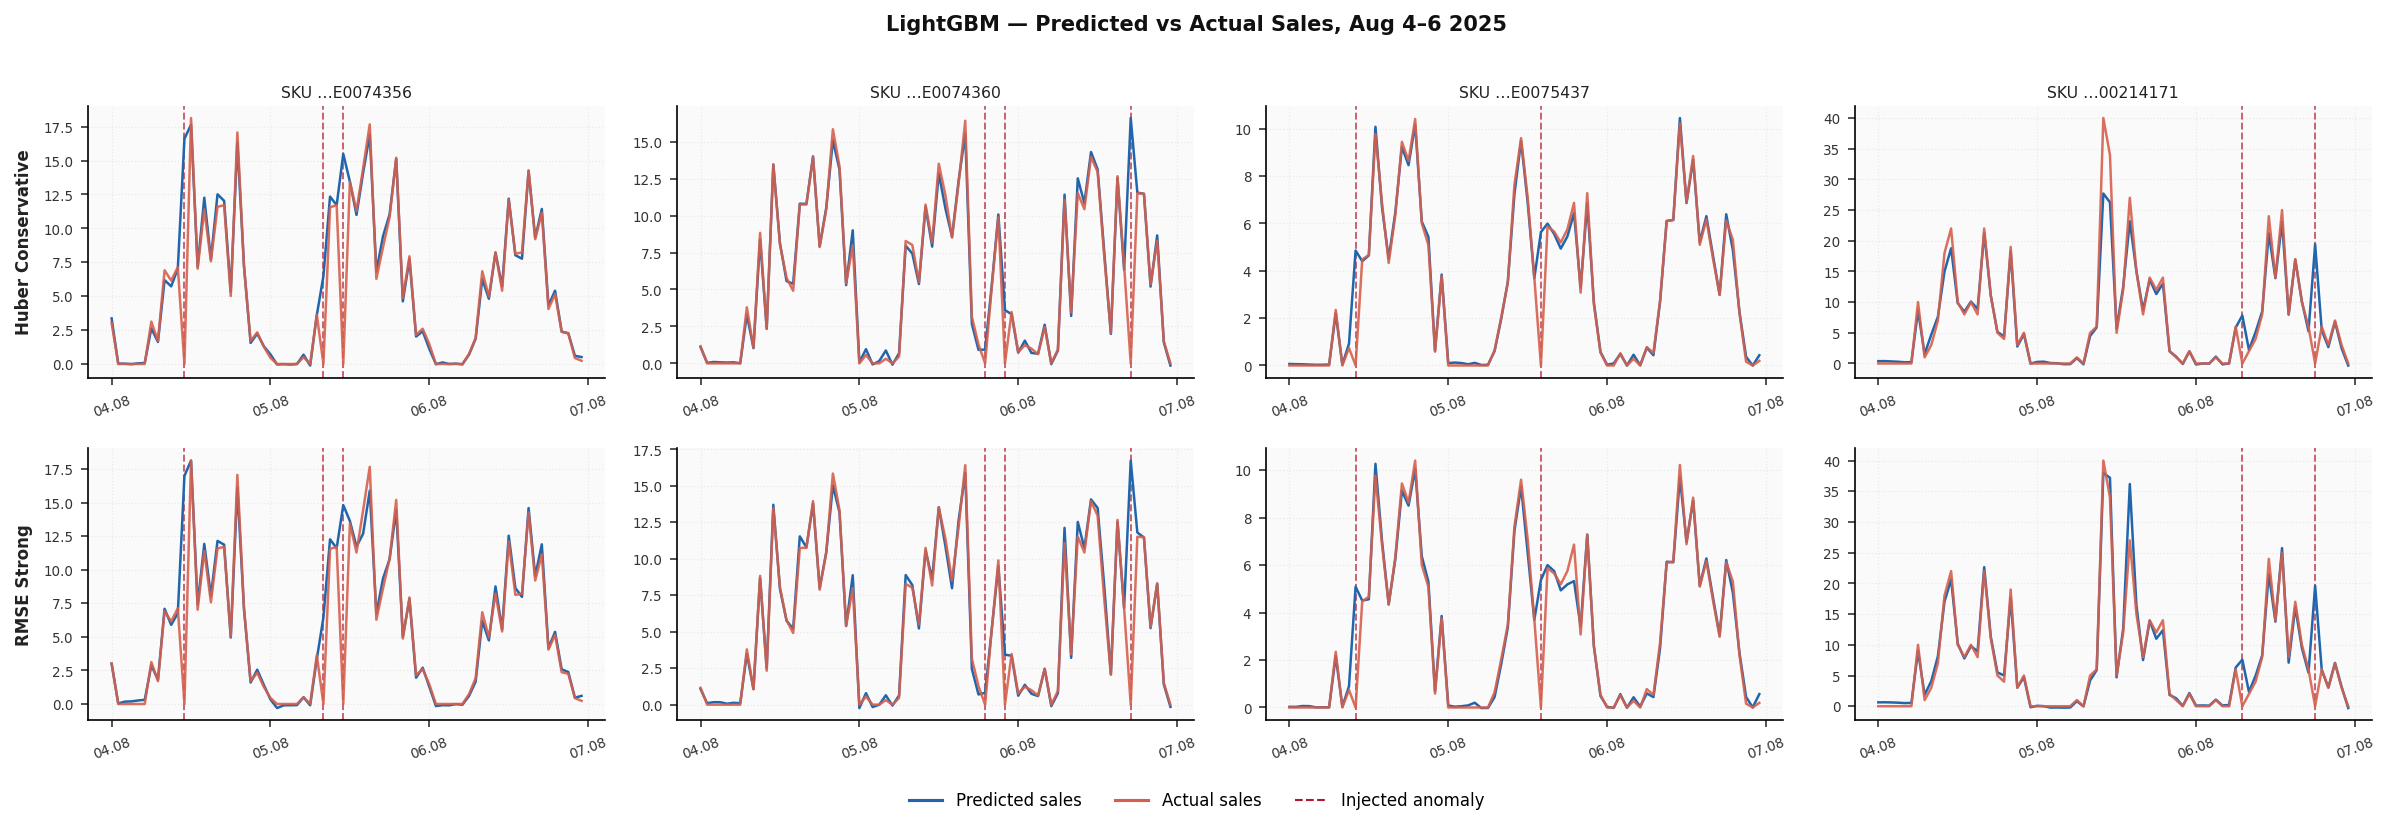

In [26]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
})

date_from = pd.Timestamp('2025-08-04')
date_to   = pd.Timestamp('2025-08-07')

top4 = (df_aug_zero[
    (df_aug_zero['date'] >= date_from) &
    (df_aug_zero['date'] < date_to)
].groupby('product').size()
 .sort_values(ascending=False).head(4).index.tolist())

if len(top4) < 4:
    top4 = (df_aug_zero.groupby('product').size()
            .sort_values(ascending=False).head(4).index.tolist())

model_preds_named = [
    ('Huber Conservative', df_huber_cons),
    ('RMSE Strong',        df_rmse_strong),
]

# 2 строки (модели) × 4 колонки (товары)
fig, axes = plt.subplots(2, 4, figsize=(16, 5), dpi=150)
fig.patch.set_facecolor('white')

for col, prod in enumerate(top4):
    anomaly_hours = df_aug_zero[df_aug_zero['product'] == prod]['date']

    for row, (mname, df_p) in enumerate(model_preds_named):
        ax = axes[row, col]

        df_prod = df_p[
            (df_p['product'] == prod) &
            (df_p['date'] >= date_from) &
            (df_p['date'] < date_to)
        ].sort_values('date')

        ax.plot(df_prod['date'], df_prod['predicted_sales'],
                color='#2166AC', linewidth=1.2, label='Predicted', zorder=3)
        ax.plot(df_prod['date'], df_prod['sales'],
                color='#D6604D', linewidth=1.2, alpha=0.9, label='Actual', zorder=3)

        for ah in anomaly_hours:
            if date_from <= ah < date_to:
                ax.axvline(x=ah, color='#B2182B', linestyle='--',
                           alpha=0.7, linewidth=0.9, zorder=2)

        # Заголовок колонки — только первая строка
        if row == 0:
            ax.set_title(f'SKU …{str(prod)[-8:]}', fontsize=7.5,
                         color='#222222', pad=4)

        # Подпись модели — только первая колонка
        if col == 0:
            ax.set_ylabel(mname, fontsize=8, fontweight='bold',
                          color='#222222', labelpad=5)

        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
        ax.xaxis.set_major_locator(mdates.DayLocator())
        ax.tick_params(axis='x', labelsize=6.5, rotation=20)
        ax.tick_params(axis='y', labelsize=6.5)
        ax.grid(True, alpha=0.2, color='#aaaaaa', linewidth=0.6, linestyle=':')
        ax.set_facecolor('#FAFAFA')

handles = [
    plt.Line2D([0],[0], color='#2166AC', linewidth=1.5, label='Predicted sales'),
    plt.Line2D([0],[0], color='#D6604D', linewidth=1.5, label='Actual sales'),
    plt.Line2D([0],[0], color='#B2182B', linewidth=1,
               linestyle='--', label='Injected anomaly'),
]
fig.legend(handles=handles, loc='lower center', ncol=3,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.06))

fig.suptitle('LightGBM — Predicted vs Actual Sales, Aug 4–6 2025',
             fontsize=10, fontweight='bold', color='#111111', y=1.02)

plt.tight_layout(h_pad=1.5, w_pad=1.2)
plt.savefig(r'C:\Users\User\Desktop\диплом\predicted_vs_actual_final.png',
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

[100]	valid_0's l1: 0.0309872
[200]	valid_0's l1: 0.0147493
[300]	valid_0's l1: 0.0111876
[400]	valid_0's l1: 0.00912427
[500]	valid_0's l1: 0.00783857
[600]	valid_0's l1: 0.00677664
[700]	valid_0's l1: 0.00606343
[800]	valid_0's l1: 0.00559225
[900]	valid_0's l1: 0.00519771
[1000]	valid_0's l1: 0.00488318
[1100]	valid_0's l1: 0.00460095
[1200]	valid_0's l1: 0.00439733
Top 15 features (Huber Conservative):
z_score_24h          5829
sales_vs_mean_24h    5068
rolling_mean_24h     4397
rolling_std_6h       3626
rolling_std_24h      2985
rolling_mean_6h      2852
pct_change_1h        2226
sales_lag_1h         1679
pct_change_24h       1608
hour                 1190
sales_lag_24h         980
rolling_mean_168h     776
rolling_std_168h      342
stocks_lag_1h         293
hist_p99              225


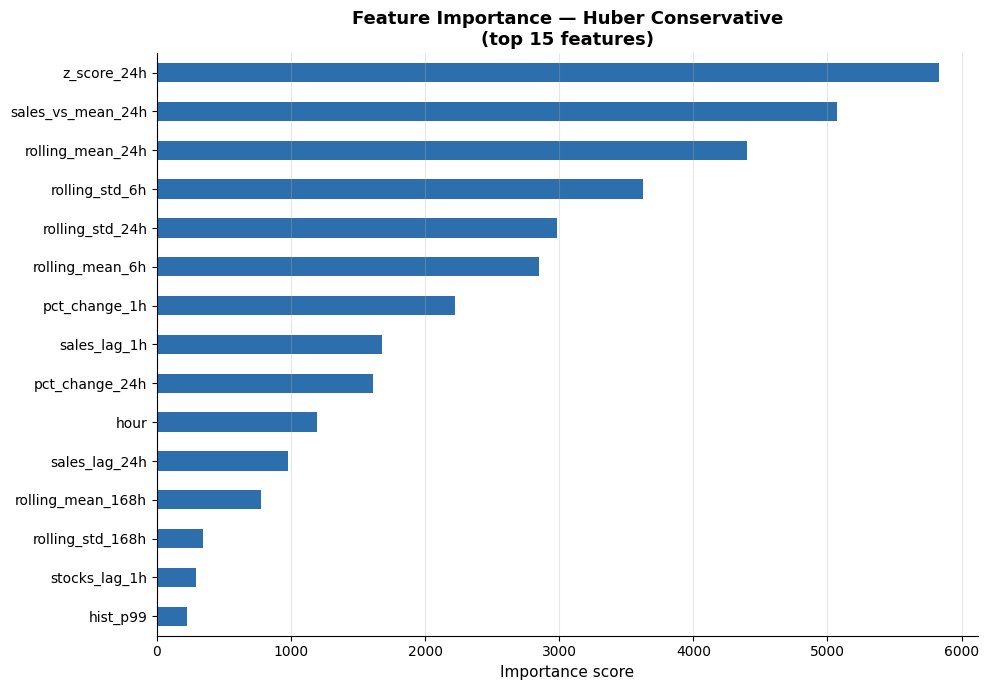

In [23]:
import matplotlib.pyplot as plt

fi_params = {
    'objective': 'huber',
    'alpha': 0.9,
    'metric': 'mae',
    'learning_rate': 0.03,
    'n_estimators': 1200,
    'num_leaves': 31,
    'max_depth': 7,
    'min_child_samples': 200,
    'reg_alpha': 0.5,
    'reg_lambda': 1.0,
    'subsample': 0.7,
    'colsample_bytree': 0.6,
    'max_bin': 255,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1
}

val_mask = (df_train['date'] >= '2025-07-25') & (df_train['date'] < '2025-08-01')

fi_model = lgb.LGBMRegressor(**fi_params)
fi_model.fit(
    X_train, y_train,
    sample_weight=np.where(y_train > 0, 3, 1),
    eval_set=[(df_train.loc[val_mask, features], df_train.loc[val_mask, 'sales'])],
    callbacks=[
        lgb.early_stopping(stopping_rounds=20, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

feat_imp = (pd.Series(fi_model.feature_importances_, index=features)
            .sort_values(ascending=False))

print("Top 15 features (Huber Conservative):")
print(feat_imp.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.head(15).sort_values().plot(kind='barh', ax=ax, color='#2C6FAC')
ax.set_title('Feature Importance — Huber Conservative\n(top 15 features)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance score', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\диплом\feature_importance_huber_cons.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
import os

OUTPUT_DIR = r'C:\Users\User\Desktop\диплом\LightGBM_fullprod_z4'
os.makedirs(OUTPUT_DIR, exist_ok=True)

configs_to_save = [
    ('2. Huber conservative', 4.0, 'huber_conservative_z4'),
    ('3. RMSE strong',        4.0, 'rmse_strong_z4'),
]

for model_name, z, fname in configs_to_save:
    df_anom = saved_anomalies[(model_name, z)]
    df_anom.to_csv(os.path.join(OUTPUT_DIR, f'{fname}.csv'), index=False)
    print(f"Saved: {fname}.csv — {len(df_anom)} anomalies, {df_anom['product'].nunique()} products")

## Final Conclusions

### Summary of Results

Four LightGBM configurations were trained on January–July 2025 data and evaluated on 
August 2025 across four z-score thresholds (z > 2.0, z > 3.0, z > 4.0, z > 5.0). 
Recall was measured against 65 manually injected zero-sales anomalies; anomaly quality 
was assessed through 20+ statistical diagnostics including historical deviation depth, 
stock availability at detection time, and operational alert volume.

**Key findings:**

*   **Huber Conservative at z > 4.0 is the recommended final configuration.** It achieves 
    92.3% recall (60/65 labelled anomalies detected), generates ~7 alerts per day (214 over 
    the test month), and maintains a mean deviation from norm of −94.5% — confirming that 
    flagged events represent genuine, deep sales collapses rather than noise. 100% of flagged 
    events occur when stock is confirmed available in both the anomaly hour and the preceding 
    hour, validating the mandatory domain filter. Notably, 40.2% of detected anomalies are 
    complete zero-sales hours, and 41.6% represent drops exceeding 50% below the product norm — 
    the highest quality signal among all four configurations.

*   **RMSE Strong at z > 4.0** achieves the highest raw recall (96.9%, 63/65) but generates 
    ~30 alerts per day — comparable to the reference algorithm from the data provider (~36/day), 
    which was identified as operationally unmanageable for a discount-format store with limited 
    staff. A system that generates alert fatigue will be ignored in practice, negating any 
    recall advantage. The 4.6 percentage point gain in recall does not justify a 4x increase 
    in daily alert volume.

*   **Huber-based configurations** consistently produce higher anomaly quality than RMSE 
    configurations at equivalent thresholds: the share of zero-sales events (40.2% vs 31.3%) 
    and deep drops exceeding 50% below norm (41.6% vs 32.1%) is meaningfully higher, reflecting 
    greater robustness to outliers during training and a tighter focus on genuine shelf-out events.

*   **The z-score threshold is an operational lever**, not a fixed parameter: it can be 
    tightened to z > 5.0 to reduce alert volume in high-traffic periods (139 alerts/month, 
    ~4.8/day), or relaxed toward z > 2.0 when maximising recall is the priority. No 
    retraining is required to adjust this parameter.

### Feature Importance Interpretation

Analysis of the Huber Conservative model confirms that short-term local context 
dominates the anomaly signal. The top five features by importance score are 
`z_score_24h` (5829), `sales_vs_mean_24h` (5068), `rolling_mean_24h` (4397), 
`rolling_std_6h` (3626), and `rolling_std_24h` (2985) — all derived from the 
preceding 6–24 hours of sales activity. This indicates that the model identifies 
anomalies by comparing the current hour against the recent local baseline, rather 
than against long-term product history.

Calendar features rank mid-table: `hour` (1190) ranks above the weekly lag 
`sales_lag_24h` (980) and the weekly rolling mean `rolling_mean_168h` (776), 
reflecting strong intraday seasonality in retail sales that the model successfully 
captures.

Long-horizon product profile features contribute minimally: `hist_p99` (225) is 
the only profile feature in the top 15, and `stocks_lag_1h` (293) confirms that 
the mandatory stock filter is also informative as a feature. The near-absence of 
historical profile features in the top ranks suggests that per-hour local context 
is sufficient for anomaly detection at this granularity, and that pre-computed 
product statistics serve primarily as regularisation signals rather than primary 
predictors.

Note: the model did not trigger early stopping (validation loss improved through 
all 1200 iterations), suggesting that additional training rounds could further 
reduce validation error. This is a known characteristic of Huber loss on sparse 
intermittent demand data and does not indicate overfitting, as the regularisation 
parameters constrain model complexity independently of the iteration count.

### Methodological Positioning

The residual z-score approach consistently outperforms direct statistical thresholding. By 
modelling expected sales per product and flagging deviations from the model's prediction, the 
pipeline inherently accounts for product heterogeneity, intermittent demand, and seasonal 
patterns — factors that a fixed global threshold cannot handle.

All detected anomalies satisfy two hard domain constraints: stock must be available both at 
the anomaly hour and in the preceding hour. This eliminates false positives caused by 
legitimate stockouts or fresh deliveries not yet placed on the shelf — a key methodological 
improvement over the reference algorithm, which applied no such filter and produced a 
substantial proportion of operationally meaningless alerts.

The pipeline requires no labelled training data. Feature engineering, training, threshold 
selection, and evaluation are fully automated and reproducible. The only human input is the 
specification of the z-threshold and domain filter parameters, both of which can be adjusted 
post-deployment without retraining.

### Conclusion

The developed methodology successfully addresses the core modelling objective of this stage: 
detecting hourly sales drops caused by shelf availability failures across a large heterogeneous 
product catalogue, in the absence of labelled training data. The final system — LightGBM with 
Huber loss and conservative regularisation — achieves 92.3% recall on controlled anomalies 
while generating approximately 7 alerts per day, representing an 80% reduction in daily alert 
volume relative to the reference algorithm from the data provider. The z-score threshold can 
be adjusted at deployment time without retraining. The following stages of the study extend 
this pipeline through comparison with the provider's algorithm on real anomaly data and 
cluster-level analysis of detected events.